In [1]:
import sys
from pathlib import Path

BASE_DIR = Path.cwd().parent

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from datetime import datetime
plt.style.use('seaborn-v0_8-darkgrid')

# Understanding the data

In [3]:
sales_train_eval = pd.read_csv(BASE_DIR / 'data'/'m5-forecasting-accuracy'/'sales_train_evaluation.csv')
sales_train_val =  pd.read_csv(BASE_DIR / 'data'/'m5-forecasting-accuracy'/'sales_train_validation.csv')
calender = pd.read_csv(BASE_DIR/'data'/'m5-forecasting-accuracy'/'calendar.csv')
sell_prices = pd.read_csv(BASE_DIR/'data'/'m5-forecasting-accuracy'/'sell_prices.csv')


In [4]:
sales_train_eval.info()

<class 'pandas.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1947 entries, id to d_1941
dtypes: int64(1941), str(6)
memory usage: 452.9 MB


In [5]:
np.finfo(np.float16)

finfo(resolution=0.001, min=-6.55040e+04, max=6.55040e+04, dtype=float16)

In [6]:

def reduce_mem_usage(df):
    start_mem = df.memory_usage().sum() / 1024**2
    print(f'Initial memory usage: {start_mem:.2f} MB')

    for col in df.columns:
        # Use Pandas-specific type checkers
        if pd.api.types.is_integer_dtype(df[col]):
            c_min = df[col].min()
            c_max = df[col].max()
            if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)
            elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)
            elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                df[col] = df[col].astype(np.int32)
            else:
                df[col] = df[col].astype(np.int64)

        elif pd.api.types.is_float_dtype(df[col]):
            c_min = df[col].min()
            c_max = df[col].max()
            if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                df[col] = df[col].astype(np.float16)
            elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                df[col] = df[col].astype(np.float32)
            else:
                df[col] = df[col].astype(np.float64)

        elif pd.api.types.is_object_dtype(df[col]) or isinstance(df[col].dtype, pd.StringDtype):
            # Only convert to category if it saves space (low cardinality)
            if df[col].nunique() / len(df) < 0.5:
                df[col] = df[col].astype('category')

    end_mem = df.memory_usage().sum() / 1024**2
    print(f'Final memory usage: {end_mem:.2f} MB')
    print(f'Decreased by {100 * (start_mem - end_mem) / start_mem:.1f}%')
    
    return df

def down_data(df):
    """create a dataframe and optimize its memory usage"""
    # df = pd.read_csv(file, parse_dates=True, keep_date_col=True)
    df = reduce_mem_usage(df)
    return df

In [7]:
sales_train_val = down_data(sales_train_val)
calender = down_data(calender)
sales_train_eval = down_data(sales_train_eval)
sell_prices = down_data(sell_prices)


Initial memory usage: 446.40 MB
Final memory usage: 94.03 MB
Decreased by 78.9%
Initial memory usage: 0.21 MB
Final memory usage: 0.06 MB
Decreased by 73.0%
Initial memory usage: 452.91 MB
Final memory usage: 95.17 MB
Decreased by 79.0%
Initial memory usage: 208.77 MB
Final memory usage: 45.69 MB
Decreased by 78.1%


In [8]:
# sales_train_val and eval are in wide format, so as a first step, aggregate the levels, by identifying unique ids in each category cols
sales_train_eval


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30485,FOODS_3_823_WI_3_evaluation,FOODS_3_823,FOODS_3,FOODS,WI_3,WI,0,0,2,2,...,1,0,3,0,1,1,0,0,1,1
30486,FOODS_3_824_WI_3_evaluation,FOODS_3_824,FOODS_3,FOODS,WI_3,WI,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
30487,FOODS_3_825_WI_3_evaluation,FOODS_3_825,FOODS_3,FOODS,WI_3,WI,0,6,0,2,...,0,0,1,2,0,1,0,1,0,2
30488,FOODS_3_826_WI_3_evaluation,FOODS_3_826,FOODS_3,FOODS,WI_3,WI,0,0,0,0,...,1,1,1,4,6,0,1,1,1,0


In [9]:
unique_states = sales_train_val['state_id'].unique()
unique_stores = sales_train_val['store_id'].unique()
item_unique = sales_train_val['item_id'].unique()
dept_unique = sales_train_val['dept_id'].unique()

print("unique states:\t",unique_states)
print("\nunique stores:\t",unique_stores)
print("\ndept unique:\t",dept_unique)
print("\nitemunique:\t",item_unique)
print("\ntotal items: ",len(item_unique)*len(unique_stores)*1941)


unique states:	 ['CA', 'TX', 'WI']
Categories (3, str): ['CA', 'TX', 'WI']

unique stores:	 ['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2', 'WI_3']
Categories (10, str): ['CA_1', 'CA_2', 'CA_3', 'CA_4', ..., 'TX_3', 'WI_1', 'WI_2', 'WI_3']

dept unique:	 ['HOBBIES_1', 'HOBBIES_2', 'HOUSEHOLD_1', 'HOUSEHOLD_2', 'FOODS_1', 'FOODS_2', 'FOODS_3']
Categories (7, str): ['FOODS_1', 'FOODS_2', 'FOODS_3', 'HOBBIES_1', 'HOBBIES_2', 'HOUSEHOLD_1', 'HOUSEHOLD_2']

itemunique:	 ['HOBBIES_1_001', 'HOBBIES_1_002', 'HOBBIES_1_003', 'HOBBIES_1_004', 'HOBBIES_1_005', ..., 'FOODS_3_823', 'FOODS_3_824', 'FOODS_3_825', 'FOODS_3_826', 'FOODS_3_827']
Length: 3049
Categories (3049, str): ['FOODS_1_001', 'FOODS_1_002', 'FOODS_1_003', 'FOODS_1_004', ..., 'HOUSEHOLD_2_513', 'HOUSEHOLD_2_514', 'HOUSEHOLD_2_515', 'HOUSEHOLD_2_516']

total items:  59181090


*sales_train_val* contains the items, category, category_id, store_id, state_id, and days with item sold in number of units
* There are ~30000 entries, each corresponding to an item avaialable across stores
* 3 states, 10 stores (4 in CA,3 in TX, 3 in WI)
* ~3000 unique items in 3 categories (Hobbies, household, foods)
* total entries in the long format: 59 million

### Checking for NaN or missing values

In [10]:
print("shape:\t",sales_train_eval.shape)
print("\ndate range:\t",calender['date'].min(),' to ',calender['date'].max())
print("\nmissing values",sales_train_val.isnull().sum().sum())

day_cols = [col for col in sales_train_val.columns if col.startswith('d_')]
zero_counts = (sales_train_val[day_cols] == 0).sum(axis=1)
print("\nRows with all zeros:", (zero_counts == len(day_cols)).sum())


shape:	 (30490, 1947)

date range:	 2011-01-29  to  2016-06-19

missing values 0

Rows with all zeros: 0


In [11]:
# Reshape data to long format for easier aggregation
day_cols = [col for col in sales_train_val.columns if col.startswith('d_')]
id_cols = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']

# Melt the data
sales_long = sales_train_val.melt(
    id_vars=id_cols,
    value_vars=day_cols,
    var_name='d',
    value_name='sales'
)
sales_long = sales_long.merge(calender[['d', 'date']], on='d', how='left')
# sales_long.head(10)
sales_long['date'] = pd.to_datetime(sales_long['date'])
sales_long.head(10)

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29
5,HOBBIES_1_006_CA_1_validation,HOBBIES_1_006,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29
6,HOBBIES_1_007_CA_1_validation,HOBBIES_1_007,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29
7,HOBBIES_1_008_CA_1_validation,HOBBIES_1_008,HOBBIES_1,HOBBIES,CA_1,CA,d_1,12,2011-01-29
8,HOBBIES_1_009_CA_1_validation,HOBBIES_1_009,HOBBIES_1,HOBBIES,CA_1,CA,d_1,2,2011-01-29
9,HOBBIES_1_010_CA_1_validation,HOBBIES_1_010,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29


In [12]:
# # reshaping the long format, only aggregating at higher level due to the size of the dataset
# day_cols  = [col for col in sales_train_eval.columns if col.startswith('d_')]

# state_cols = ['state_id']+day_cols 

# state_lvl = sales_train_eval[state_cols]
# #make it long format
# state_lvl = state_lvl.melt(id_vars=['state_id'],value_vars=day_cols,var_name='d',value_name='sales')

# state_lvl = state_lvl.merge(calender,on='d',how='left')
# state_lvl['date'] = pd.to_datetime(state_lvl['date'])
# state_lvl



### Item sale patterns

In [12]:
hobbies_1_ca_1  = sales_long[(sales_long['id']=='HOBBIES_1_001_CA_1_validation')]
food_1_ca_1 = sales_long[(sales_long['id'])=='FOODS_1_001_CA_1_validation']
household_1_ca_1 = sales_long[(sales_long['id'])=='HOUSEHOLD_1_001_CA_1_validation']


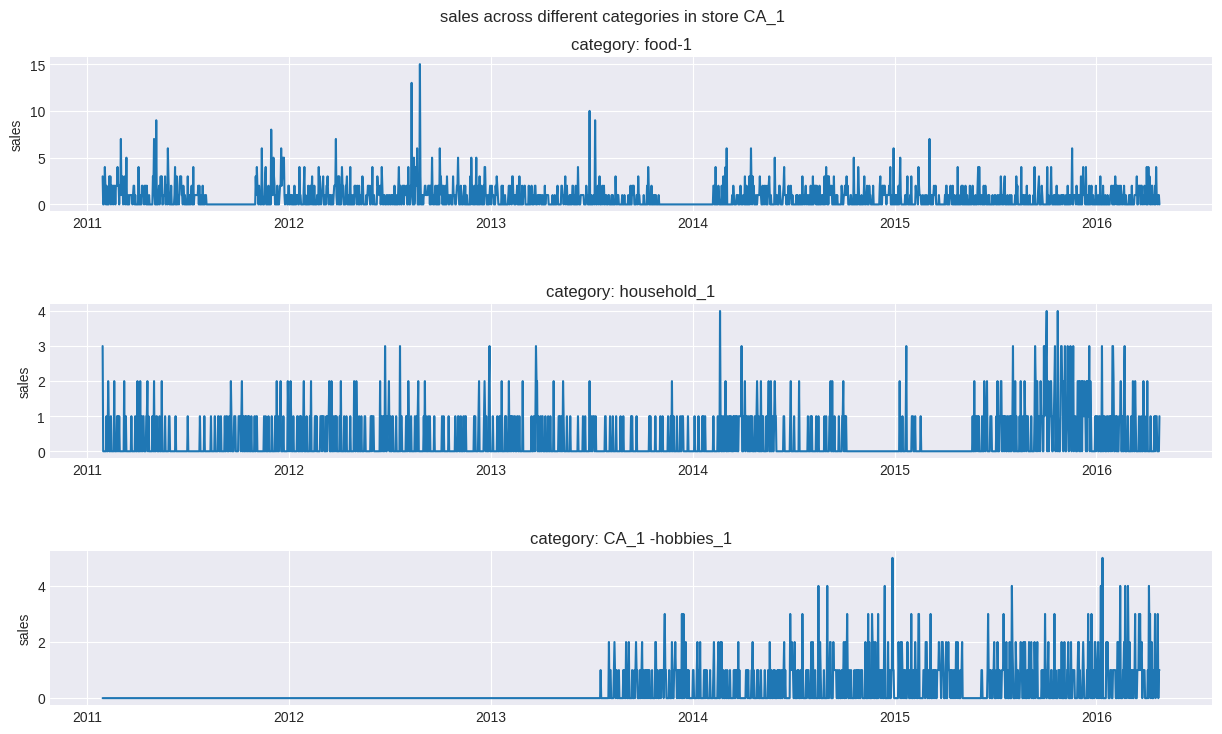

In [13]:
fig,ax = plt.subplots(nrows=3,ncols=1,figsize=(15,8))
fig.suptitle("sales across different categories in store CA_1")
ax[0].plot(food_1_ca_1['date'], food_1_ca_1['sales'])
ax[0].set_title('category: food-1')
ax[0].set_ylabel('sales')

ax[1].plot(household_1_ca_1['date'],household_1_ca_1['sales'])
ax[1].set_title('category: household_1')
ax[1].set_ylabel("sales")

ax[2].plot(hobbies_1_ca_1['date'], hobbies_1_ca_1['sales'])
ax[2].set_title('category: CA_1 -hobbies_1')
ax[2].set_ylabel("sales")


# ax[0].set_ylabel('Sales')
plt.subplots_adjust(hspace=0.6, wspace=0.3, top=0.92)



Looking at the plots,we can see that, the data is intermittent (we have to classify properly using $CV^2$ and ADI (Average demand intervel)),
before focusing on this, we go top-down approach to identify patterns and trends at global level

## Aggregate
Aggregating the data at global level to figure out the patterns (seasonality, trend)

### Different levels:

Levels : State, Stores, Categories (Foods,Household,Hobbies), Departments (Foods_1,2,3,Household_1,2,Hobbies_1,2),items (Foods_1_1,2_2,etc.)

1. State level:  state vs sales(total)
2. Store level: Stores vs sales
3. State - category level: state,category vs sales 
4. Store - category level: store,category vs sales
5. Store - dept level :  store, dept vs sales


## 1. State Level

In [14]:
state_lvl = sales_long.groupby(['state_id' , 'date'])['sales'].sum().reset_index()
state_lvl

,state_id,date,sales
0,CA,2011-01-29,14195
1,CA,2011-01-30,13805
2,CA,2011-01-31,10108
3,CA,2011-02-01,11047
4,CA,2011-02-02,9925
...,...,...,...
5734,WI,2016-04-20,10595
5735,WI,2016-04-21,10943
5736,WI,2016-04-22,12807
5737,WI,2016-04-23,14862


In [15]:
# import gc
# gc.collect(sales_long)

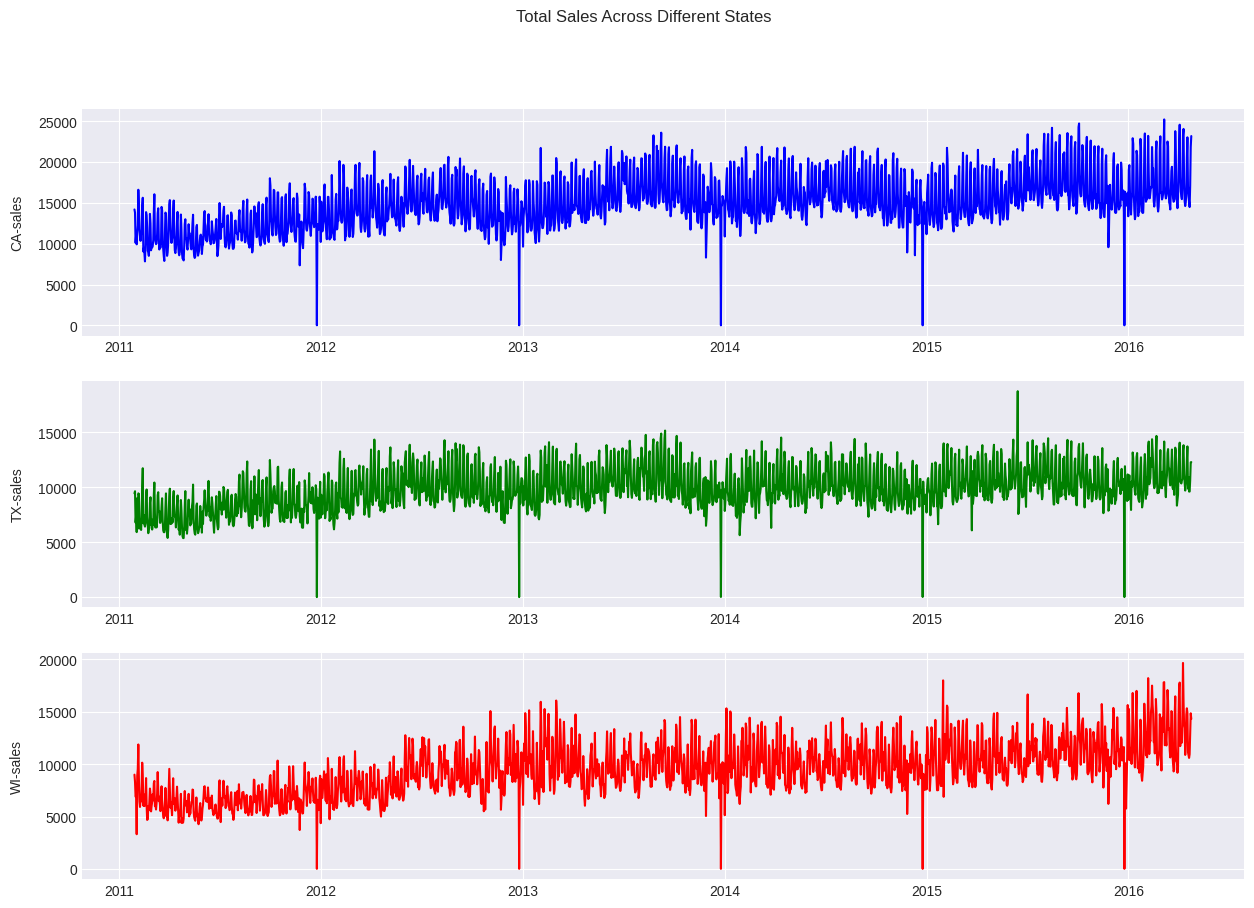

In [16]:
figs,axs = plt.subplots(nrows=3,ncols=1,figsize=(15,10))
color = ['blue','green','red']
figs.suptitle("Total Sales Across Different States")
for idx,state in enumerate(state_lvl['state_id'].unique()):
    mask = state_lvl['state_id']==state

    axs[idx].plot(state_lvl[mask]['date'],state_lvl[mask]['sales'],c=color[idx])
    axs[idx].set_ylabel(f'{state}-sales',labelpad=10)


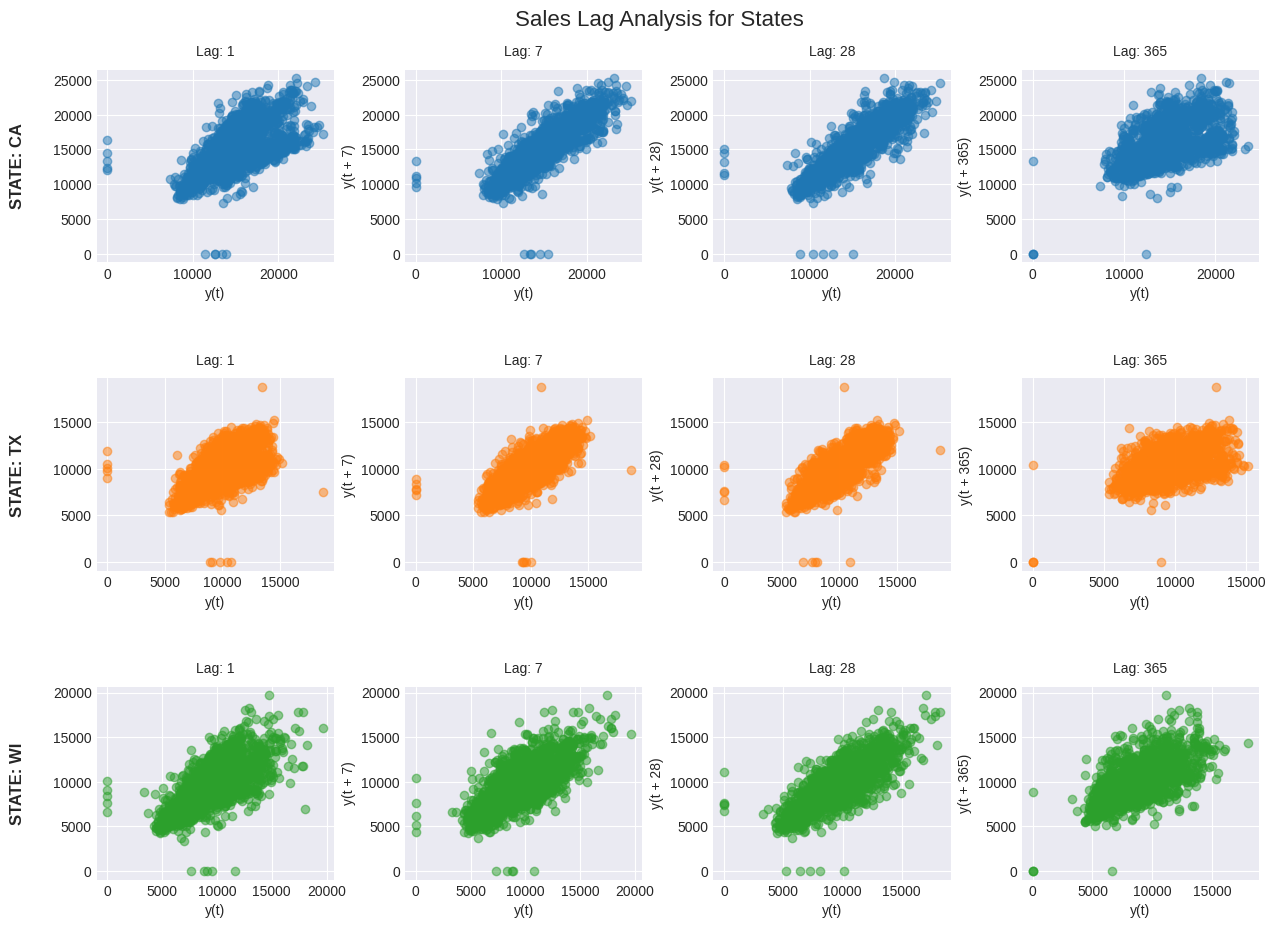

In [23]:
from pandas.plotting import lag_plot
from statsmodels.graphics.tsaplots import  plot_acf


fig_2,ax_2 = plt.subplots(nrows=3,ncols=4,figsize=(15,10))
fig_2.suptitle(f"Sales Lag Analysis for States", fontsize=16, y=0.98)
lags = [1,7,28,365]
row_colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Blue, Orange, Green (Standard Matplotlib Tab10)
for idx,state in enumerate(state_lvl['state_id'].unique()):
    for jdx,lag in enumerate(lags):
        mask = state_lvl['state_id']==state
        ax_2[idx, 0].set_ylabel(f"STATE: {state}", fontweight='bold', fontsize=12, labelpad=20)
        lag_plot(state_lvl[mask]['sales'],lag=lag,ax=ax_2[idx,jdx],c=row_colors[idx % len(row_colors)], alpha=0.5)
        ax_2[idx, jdx].set_title(f'Lag: {lag}', fontsize=10, pad=10)
        # break
plt.subplots_adjust(hspace=0.6, wspace=0.3, top=0.92)


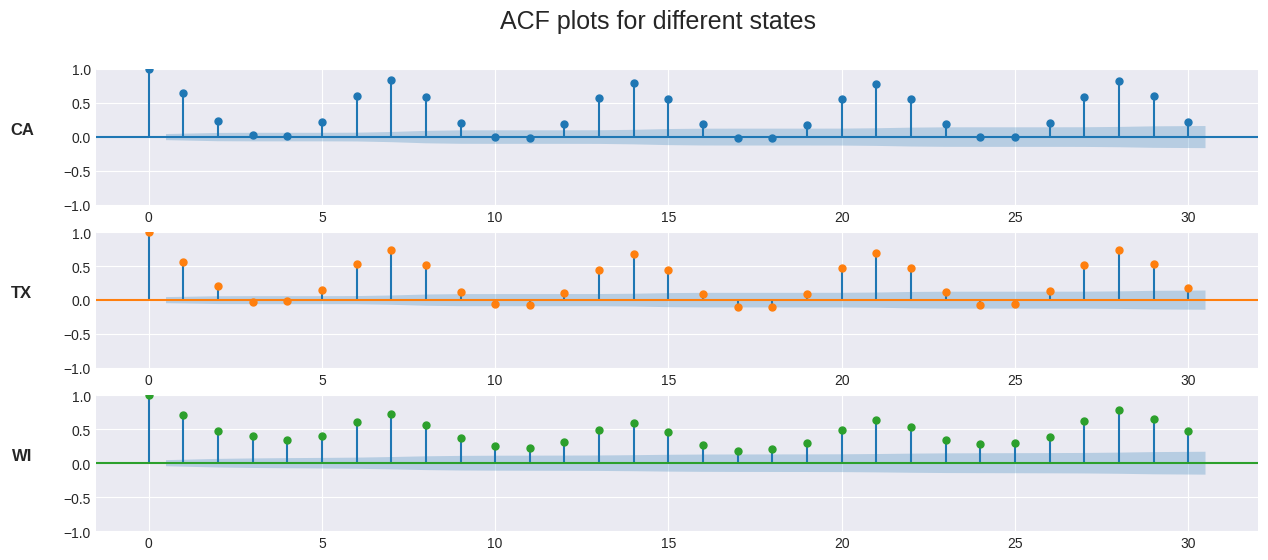

In [18]:
# ploting the ACF for different state 
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(15,6))
row_colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] 
fig.suptitle(f"ACF plots for different states",fontsize=18)
for idx, state in enumerate(state_lvl['state_id'].unique()):
    # Filter data for the specific state and category
    mask = state_lvl['state_id']==state
    sales_data = state_lvl[mask]['sales']
    # 2. Plot ACF onto the specific row
    # lags=30 shows the correlation for the last month
    plot_acf(sales_data, lags=30, ax=ax[idx], color=row_colors[idx], title="")
    # 3. Custom Annotation & Spacing
    ax[idx].set_ylabel(f"{state}", fontweight='bold', fontsize=12, rotation=0, labelpad=30)
    # ax[idx].set_title(f"Autocorrelation: {state} ({cat_id})", loc='right', fontsize=10)


The lag plots and ACF plots clearly reveal a weekly seasonality

### Decomposition:
To see the underlying patterns (seasonality, trend and  resid), we decompose the data

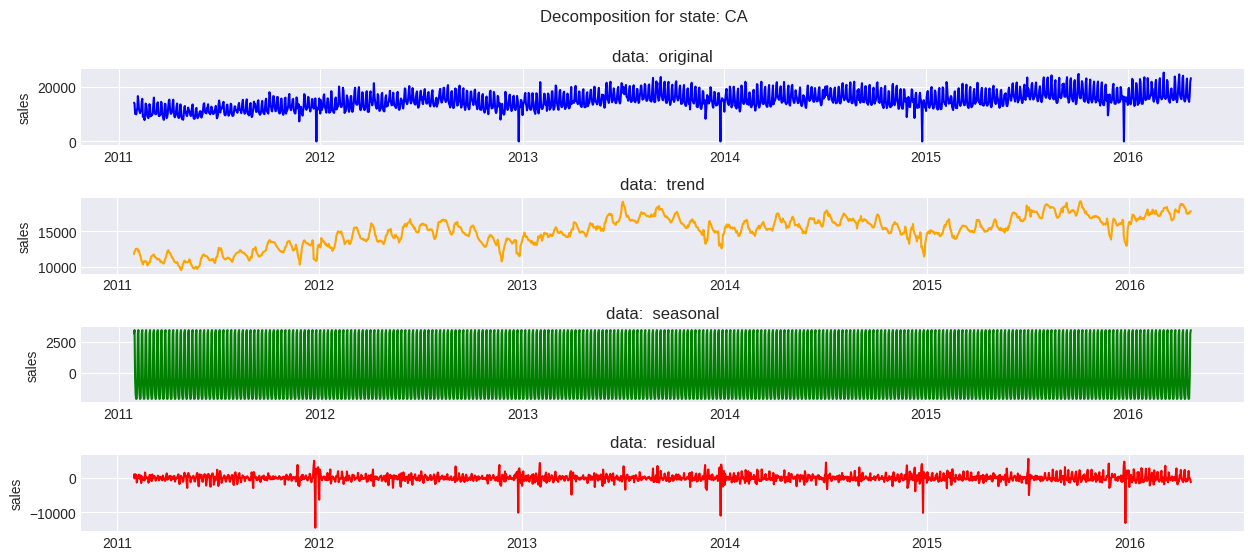

In [24]:
from statsmodels.tsa.seasonal import seasonal_decompose

# only do it for one state and one category (FOODS)
state= 'CA'

mask = (state_lvl['state_id'] == state) 

sales_data_state = state_lvl[mask]['sales']
dates = state_lvl[mask]['date']
decomp_CA = seasonal_decompose(sales_data_state,model='additive',period=7) #period is 7 from our acf plot,

fig_3,ax_3 = plt.subplots(nrows=4,ncols=1,figsize=(15,6))

decompos = [sales_data_state,decomp_CA.trend,decomp_CA.seasonal,decomp_CA.resid]
titles = ['original','trend','seasonal','residual']
colors  = ['blue','orange','green','red']
fig_3.suptitle(f'Decomposition for state: {state}')
for i,data in enumerate(decompos):
    ax_3[i].plot(dates,data,c=colors[i])
    ax_3[i].set_title(f'data:  {titles[i]}')
    ax_3[i].set_ylabel('sales')

plt.subplots_adjust(hspace=0.7)

Lets use a baseline model to forecast for global level (although in reality, we do a bottom-up modelling- model the lowest level and aggregate)

### 1. Baseline models

In [25]:
calender['date'] = pd.to_datetime(calender['date'])
state_lvl_merged  = state_lvl.merge(calender,on='date',how='left')
# state_lvl_merged|

Figuring out correlation on exogeneous variables,
1. snap_CA,snap_TX,snap_WI
2. sell price

In [26]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing

# split the data to train and test split, 
# for CA
state = 'CA'
mask = state_lvl_merged['state_id']==state
ca_sales = state_lvl_merged[mask].sort_values('date')
ca_train,ca_test = ca_sales.iloc[:-28],ca_sales.iloc[-28:]
# ca_train.iloc[:,-3]
# ca_test.iloc[:,-3]

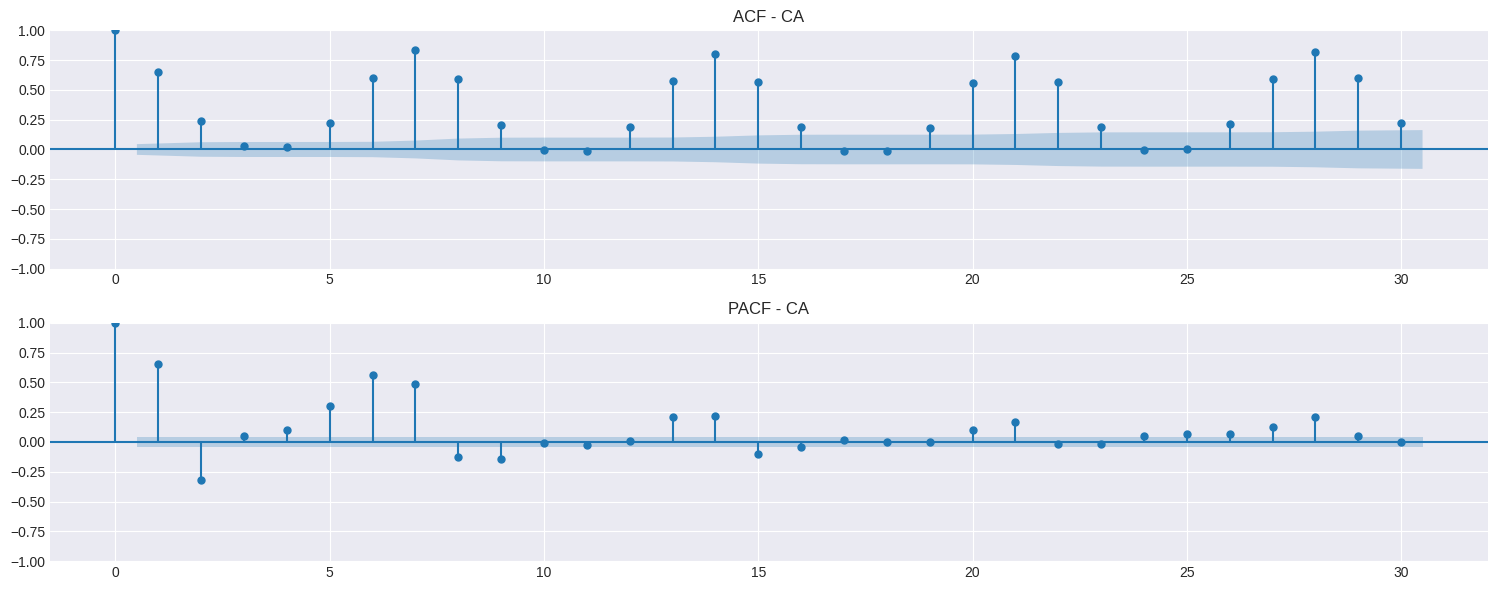

In [28]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(15, 6))
plot_acf(ca_sales['sales'], lags=30, ax=axes[0], title='ACF - CA')
plot_pacf(ca_sales['sales'], lags=30, ax=axes[1], title='PACF - CA')
plt.tight_layout()

ADF p-value (raw): 0.3930
ADF p-value (diff1): 0.0000
ADF p-value (diff1 + seasonal diff): 0.0000


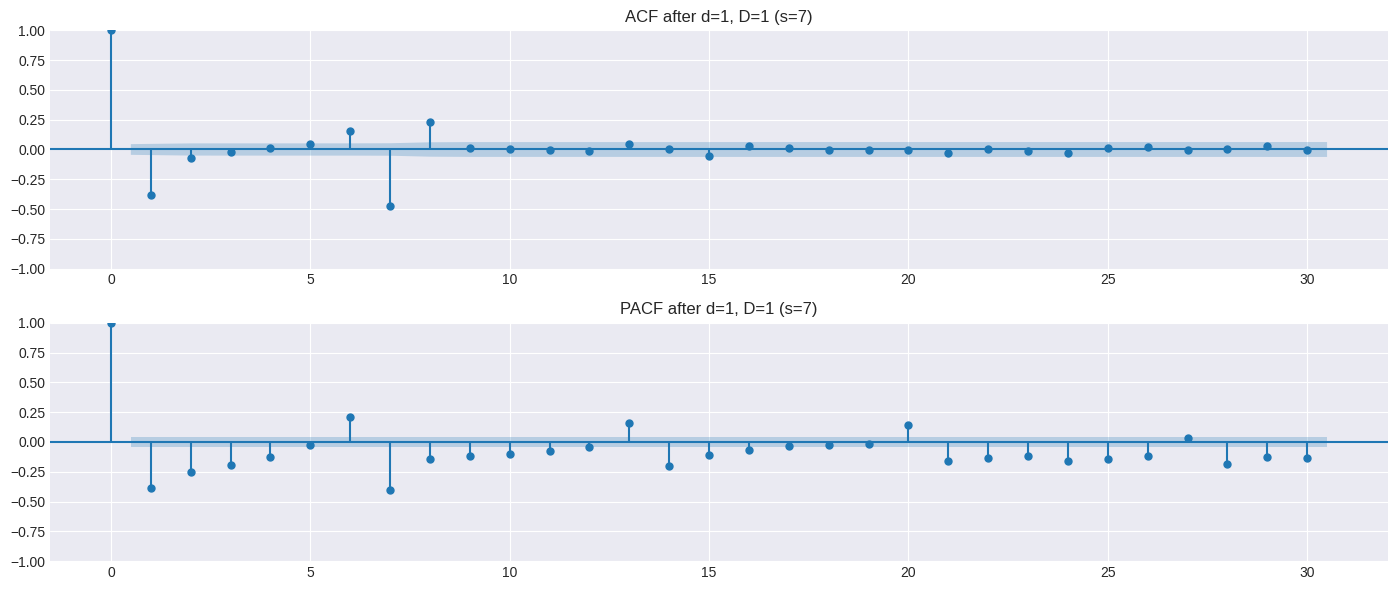

In [29]:
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt


# 1. ADF test on raw series
result = adfuller(sales_data_state)
print(f'ADF p-value (raw): {result[1]:.4f}')  # expect > 0.05 → non-stationary

# 2. First difference (removes trend)
sales_diff1 = sales_data_state.diff().dropna()
result2 = adfuller(sales_diff1)
print(f'ADF p-value (diff1): {result2[1]:.4f}')  # might still be > 0.05

# 3. Seasonal difference on top (removes weekly pattern)
sales_diff1_7 = sales_diff1.diff(7).dropna()
result3 = adfuller(sales_diff1_7)
print(f'ADF p-value (diff1 + seasonal diff): {result3[1]:.4f}')  # expect < 0.05

# 4. NOW plot ACF and PACF on the fully differenced series
fig, axes = plt.subplots(2, 1, figsize=(14, 6))
plot_acf(sales_diff1_7, lags=30, ax=axes[0], title='ACF after d=1, D=1 (s=7)')
plot_pacf(sales_diff1_7, lags=30, ax=axes[1], title='PACF after d=1, D=1 (s=7)')
plt.tight_layout()
plt.show()

In [30]:
#The five baselines 
#------------------------
# Naive, repeat the last value of training
f_naive = np.full(28,ca_train.iloc[-1,2])

# Seasonal Naive, repeat the last 28 days
f_snaive = ca_train.iloc[-28:,2]

# Rolling average (last 30 days mean)
f_rolling = np.full(28,ca_train.iloc[-30:,2].mean())

# ARIMA and SARIMA
model_arima = SARIMAX(ca_train.iloc[:,2], order=(1,1,1))# order= p,d,q
res_arima = model_arima.fit(disp=False)
f_arima = res_arima.forecast(steps=28)

model_sarima = SARIMAX(ca_train.iloc[:,2], order=(1,1,1), seasonal_order=(1,1,1,7))# order P,D,Q ,S=7
res_sarima = model_sarima.fit(disp=False)
f_sarima = res_sarima.forecast(steps=28)

model_sarima_exog = SARIMAX(ca_train.iloc[:,2],exog=ca_train.iloc[:,-3],order=(1,1,1),seasonal_order=(1,1,1,7))
res_sarima_exog = model_sarima_exog.fit(disp=False)
f_sarima_exog = res_sarima_exog.forecast(steps=28,exog=ca_test.iloc[:,-3])

# exponential smoothing
#1.simple exponential smoothing

model_ses = SimpleExpSmoothing(ca_train.iloc[:,2]).fit(smoothing_level=0.3,optimized=False)
f_ses =  model_ses.forecast(28)

#2. Holt expo smoothing, # trend only
model_holt = ExponentialSmoothing(ca_train.iloc[:,2],trend='add',seasonal='add',seasonal_periods=7).fit(optimized=True)
f_holt = model_holt.forecast(28)

# 3. Compare Results
results = {
    "Naive": np.sqrt(mean_squared_error(ca_test.iloc[:,2], f_naive)),
    "S-Naive": np.sqrt(mean_squared_error(ca_test.iloc[:,2], f_snaive)),
    "Rolling": np.sqrt(mean_squared_error(ca_test.iloc[:,2], f_rolling)),
    "ARIMA": np.sqrt(mean_squared_error(ca_test.iloc[:,2], f_arima)),
    "SARIMA": np.sqrt(mean_squared_error(ca_test.iloc[:,2], f_sarima)),
    "SARIMA_exog":np.sqrt(mean_squared_error(ca_test.iloc[:,2],f_sarima_exog)),
    "Exponential Smooth":np.sqrt(mean_squared_error(ca_test.iloc[:,2],f_ses)),
    "Holt Expo Smooth": np.sqrt(mean_squared_error(ca_test.iloc[:,2],f_holt))

}
# print(results)
results

{'Naive': np.float64(4659.536170202842),
 'S-Naive': np.float64(1305.1805430667437),
 'Rolling': np.float64(3299.872678087338),
 'ARIMA': np.float64(3445.8550300684947),
 'SARIMA': np.float64(1099.98422559197),
 'SARIMA_exog': np.float64(808.0238006648107),
 'Exponential Smooth': np.float64(3673.0519226702363),
 'Holt Expo Smooth': np.float64(1073.7273246364762)}

In [32]:
print(f"\nHolt-Winters parameters found:")
print(f"α (level):    {model_holt.params['smoothing_level']:.3f}")
print(f"β (trend):    {model_holt.params['smoothing_trend']:.3f}")
print(f"γ (seasonal): {model_holt.params['smoothing_seasonal']:.3f}")


Holt-Winters parameters found:
α (level):    0.218
β (trend):    0.000
γ (seasonal): 0.040


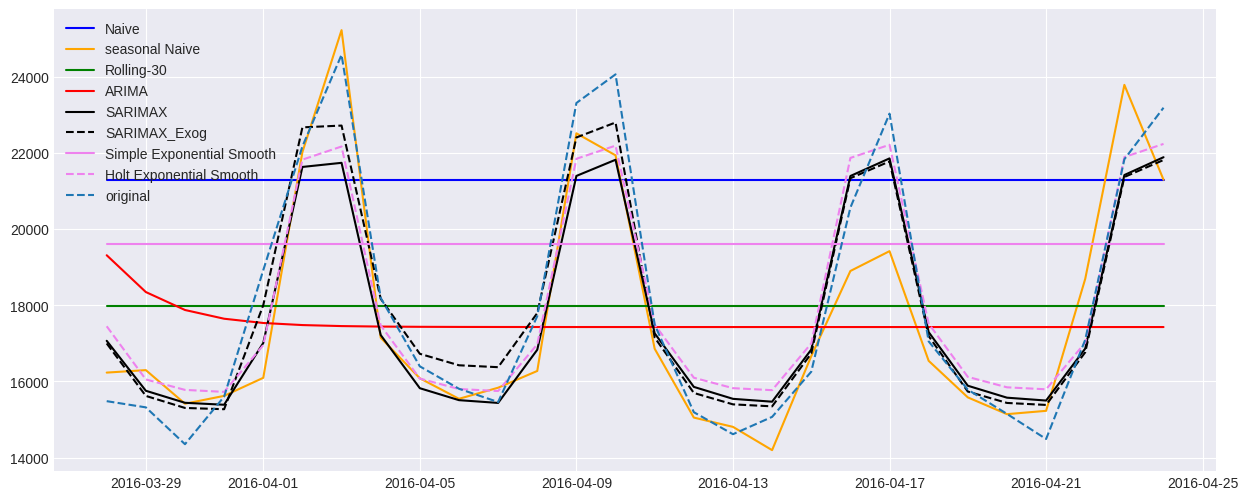

In [27]:
#plotting the predicted vs real\
plt.figure(figsize=(15,6))
test_dates = ca_test['date']
plt.plot(test_dates,f_naive,'blue',label='Naive')
plt.plot(test_dates,f_snaive,'orange',label='seasonal Naive')
plt.plot(test_dates,f_rolling,'green',label='Rolling-30')
plt.plot(test_dates,f_arima,'red',label='ARIMA')
plt.plot(test_dates,f_sarima,'black',label='SARIMAX')
plt.plot(test_dates,f_sarima_exog,'black',linestyle='--',label='SARIMAX_Exog')
plt.plot(test_dates,f_ses,'violet',label='Simple Exponential Smooth')
plt.plot(test_dates,f_holt,'violet',linestyle='--',label='Holt Exponential Smooth')

plt.plot(test_dates,ca_test['sales'],linestyle='--',label='original')
# plt.plot(test_dates,ca_test['sales'],label='seasonal Naive')
# plt.plot(test_dates,f_rolling,'green',label='Rolling-30')
# plt.plot(test_dates,f_snaive,'red',label='ARIMA')
# plt.plot(test_dates,f_snaive,'black',label='SARIMAX')
plt.legend()


### Time Series Models
From the above plot, three models perform neatly:
1. Seasonal Naive, without any modelling, it give us 1305 in mse
2. Sarima (sarima exog): best with snap variable , least mse ~ 800
3. Exponential Smoothing (Holts): captures seasonality and trend (no possiblity for exog variable)

### Regression Models:
Now, we look at different regression models at global level

In [28]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import OneHotEncoder

def make_features(df):
    df = df.copy()
    
    # Calendar features — capture weekly seasonality
    df['day_of_week']   = df['date'].dt.dayofweek      # 0=Monday, 6=Sunday
    df['day_of_month']  = df['date'].dt.day
    df['week_of_year']  = df['date'].dt.isocalendar().week.astype(int)
    df['month']         = df['date'].dt.month
    
    # Lag features — give the model memory of past sales
    df['lag_7']         = df['sales'].shift(7)    # same day last week
    df['lag_14']        = df['sales'].shift(14)   # same day 2 weeks ago
    df['lag_28']        = df['sales'].shift(28)   # same day 4 weeks ago
    
    # Rolling features — local trend signal
    df['rolling_mean_7']  = df['sales'].shift(1).rolling(7).mean()
    df['rolling_mean_28'] = df['sales'].shift(1).rolling(28).mean()
    df['rolling_std_7']   = df['sales'].shift(1).rolling(7).std()
    
    return df

ca_df = ca_sales[['date','sales','snap_CA']]
ca_df = make_features(ca_df)
ca_df = ca_df.dropna()

ca_df

,date,sales,snap_CA,day_of_week,day_of_month,week_of_year,month,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_28,rolling_std_7
28,2011-02-26,13652,0,5,26,8,2,13870.0,14610.0,14195.0,10823.428571,11459.642857,2248.513498
29,2011-02-27,12491,0,6,27,8,2,13465.0,15630.0,13805.0,10792.285714,11440.250000,2200.276779
30,2011-02-28,9196,0,0,28,9,2,11997.0,9044.0,10108.0,10653.142857,11393.321429,2027.067293
31,2011-03-01,9782,1,1,1,9,3,9130.0,9496.0,11047.0,10253.000000,11360.750000,1993.762106
32,2011-03-02,9537,1,2,2,9,3,8941.0,8844.0,9925.0,10346.142857,11315.571429,1947.241932
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1908,2016-04-20,15148,0,2,20,16,4,14614.0,15807.0,15141.0,17481.428571,18091.607143,3133.763651
1909,2016-04-21,14488,0,3,21,16,4,15069.0,15459.0,15228.0,17557.714286,18091.857143,3057.909237
1910,2016-04-22,17095,0,4,22,16,4,16255.0,17714.0,18694.0,17474.714286,18065.428571,3143.407849
1911,2016-04-23,21834,0,5,23,16,4,20564.0,23311.0,23787.0,17594.714286,18008.321429,3104.882108


Linear Regression RMSE: 777.33

Feature weights:
            feature      weight
10          snap_CA  632.181850
0       day_of_week  127.419054
3             month   14.624091
4             lag_7    0.350676
6            lag_28    0.258686
5            lag_14    0.240730
8   rolling_mean_28    0.220839
9     rolling_std_7   -0.040639
7    rolling_mean_7   -0.078006
2      week_of_year  -17.914930
1      day_of_month  -45.265540

Ridge Regression RMSE: 789.08


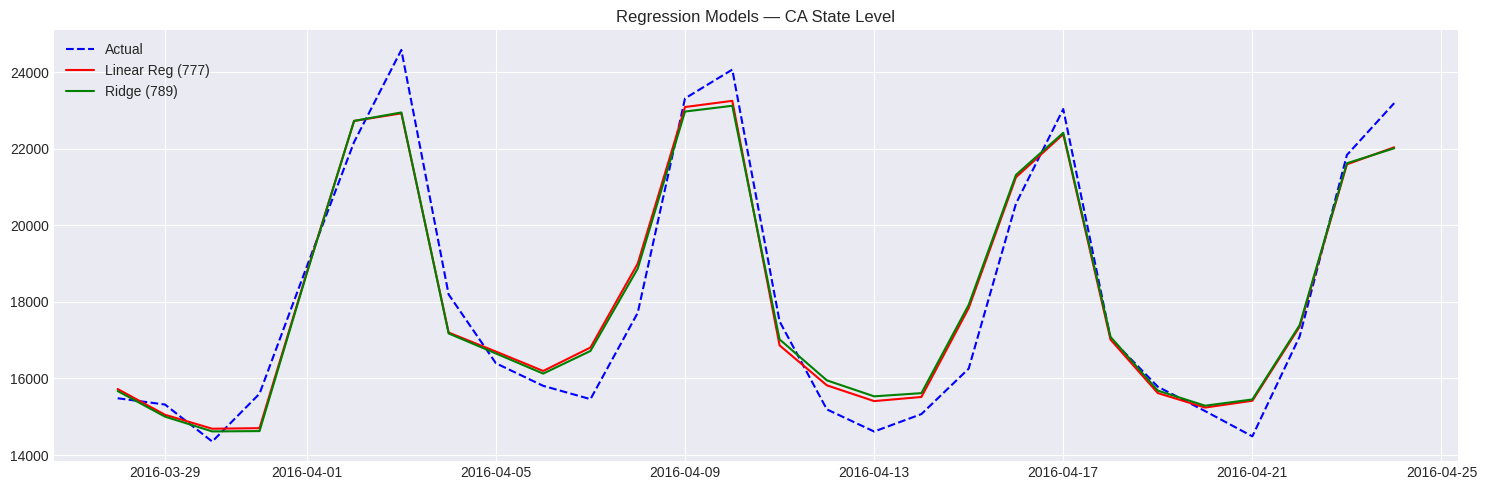

Linear Reg          : 777
Ridge               : 789
SARIMAX             : 808
Holt-Winters        : 1073
SARIMA              : 1099
S-Naive             : 1305
Rolling             : 3299
ARIMA               : 3445
Naive               : 4659


In [29]:
cutoff = ca_df['date'].max() - pd.Timedelta(days=28)
train  = ca_df[ca_df['date'] <= cutoff]
test   = ca_df[ca_df['date'] >  cutoff]

feature_cols = [
    'day_of_week', 'day_of_month', 'week_of_year', 'month',
    'lag_7', 'lag_14', 'lag_28',
    'rolling_mean_7', 'rolling_mean_28', 'rolling_std_7',
    'snap_CA'
]



X_train = train[feature_cols]
y_train = train['sales']
X_test  = test[feature_cols]
y_test  = test['sales']

lr = LinearRegression()
lr.fit(X_train, y_train)
f_lr = lr.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, f_lr))
print(f"Linear Regression RMSE: {rmse_lr:.2f}")

coef_df = pd.DataFrame({
    'feature': feature_cols,
    'weight':  lr.coef_
}).sort_values('weight', ascending=False)
print("\nFeature weights:")
print(coef_df)

ridge = Ridge(alpha=100)   # alpha controls penalty strength
ridge.fit(X_train, y_train)
f_ridge = ridge.predict(X_test)
rmse_ridge = np.sqrt(mean_squared_error(y_test, f_ridge))
print(f"\nRidge Regression RMSE: {rmse_ridge:.2f}")

plt.figure(figsize=(15, 5))
plt.plot(test['date'], y_test,   'b--', label='Actual')
plt.plot(test['date'], f_lr,     'red',    label=f'Linear Reg ({rmse_lr:.0f})')
plt.plot(test['date'], f_ridge,  'green',  label=f'Ridge ({rmse_ridge:.0f})')
plt.legend()
plt.title('Regression Models — CA State Level')
plt.tight_layout()
plt.show()

results = {
    'Naive':          4659,
    'S-Naive':        1305,
    'Rolling':        3299,
    'ARIMA':          3445,
    'SARIMA':         1099,
    'SARIMAX':         808,
    'Holt-Winters':   1073,
    'Linear Reg':     rmse_lr,
    'Ridge':          rmse_ridge,
}
for model, rmse in sorted(results.items(), key=lambda x: x[1]):
    print(f"{model:20s}: {rmse:.0f}")


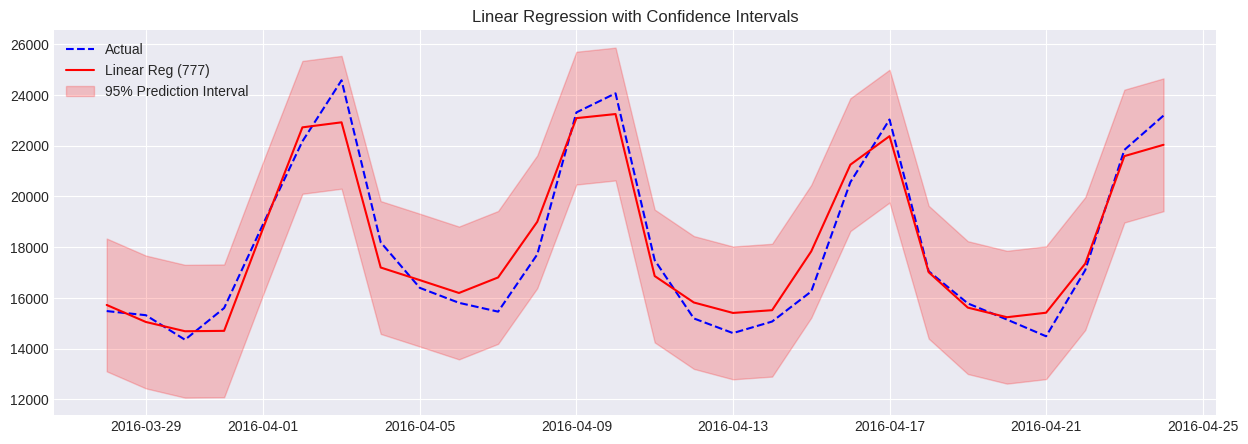

Residual std: 1335
Average interval width: 5234


In [30]:
# After fitting your linear regression:
train_preds = lr.predict(X_train)
residuals = y_train - train_preds
residual_std = np.std(residuals)

# 95% prediction interval = forecast ± 1.96 * residual_std
f_lr = lr.predict(X_test)
lower_95 = f_lr - 1.96 * residual_std
upper_95 = f_lr + 1.96 * residual_std

plt.figure(figsize=(15, 5))
plt.plot(test['date'], y_test, 'b--', label='Actual')
plt.plot(test['date'], f_lr, 'red', label=f'Linear Reg ({rmse_lr:.0f})')
plt.fill_between(test['date'], lower_95, upper_95, 
                 alpha=0.2, color='red', label='95% Prediction Interval')
plt.legend()
plt.title('Linear Regression with Confidence Intervals')
plt.show()

print(f"Residual std: {residual_std:.0f}")
print(f"Average interval width: {2 * 1.96 * residual_std:.0f}")

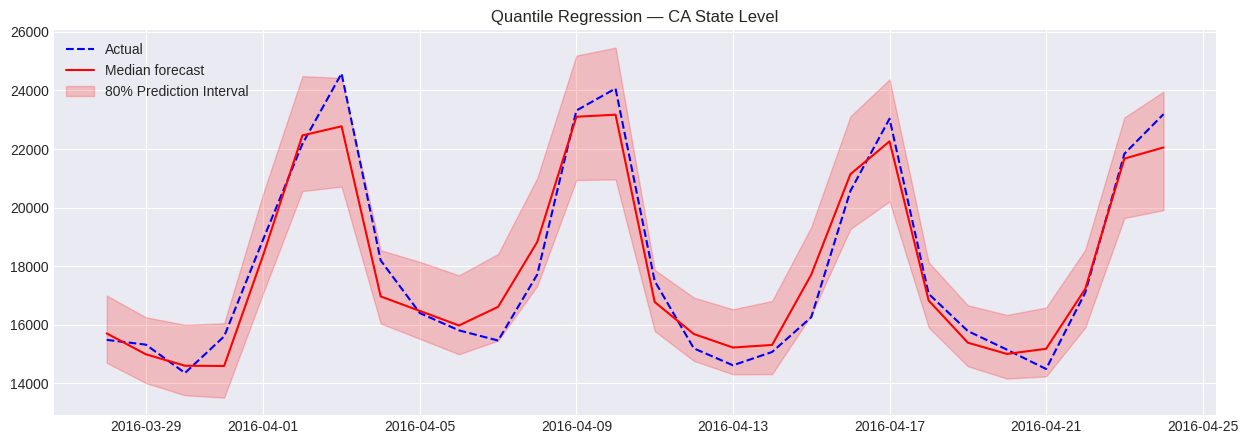

80% interval coverage: 92.9%


In [31]:
from sklearn.linear_model import QuantileRegressor

# Predict median (more robust than mean)
qr_50 = QuantileRegressor(quantile=0.5, alpha=0).fit(X_train, y_train)

# Predict lower bound (10th percentile)
qr_10 = QuantileRegressor(quantile=0.1, alpha=0).fit(X_train, y_train)

# Predict upper bound (90th percentile)  
qr_90 = QuantileRegressor(quantile=0.9, alpha=0).fit(X_train, y_train)

f_median = qr_50.predict(X_test)
f_lower  = qr_10.predict(X_test)
f_upper  = qr_90.predict(X_test)

plt.figure(figsize=(15, 5))
plt.plot(test['date'], y_test,   'b--',   label='Actual')
plt.plot(test['date'], f_median, 'red',   label='Median forecast')
plt.fill_between(test['date'], f_lower, f_upper,
                 alpha=0.2, color='red', label='80% Prediction Interval')
plt.legend()
plt.title('Quantile Regression — CA State Level')
plt.show()

# Coverage check: what % of actuals fall inside the interval?
coverage = np.mean((y_test >= f_lower) & (y_test <= f_upper))
print(f"80% interval coverage: {coverage:.1%}")
# should be close to 80% — if much lower, intervals are too narrow

## LightGBM:


In [32]:
import lightgbm as lgb

print(lgb.__version__)

4.6.0


Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 3925.56
Early stopping, best iteration is:
[59]	valid_0's rmse: 3801.13
Best iteration: 59
LightGBM RMSE: 3801.13

Feature importance:
        feature    importance
0   day_of_week  7.314330e+10
2  week_of_year  1.185515e+10
1  day_of_month  8.124997e+09
3         month  2.779798e+09
4       snap_CA  1.728102e+09


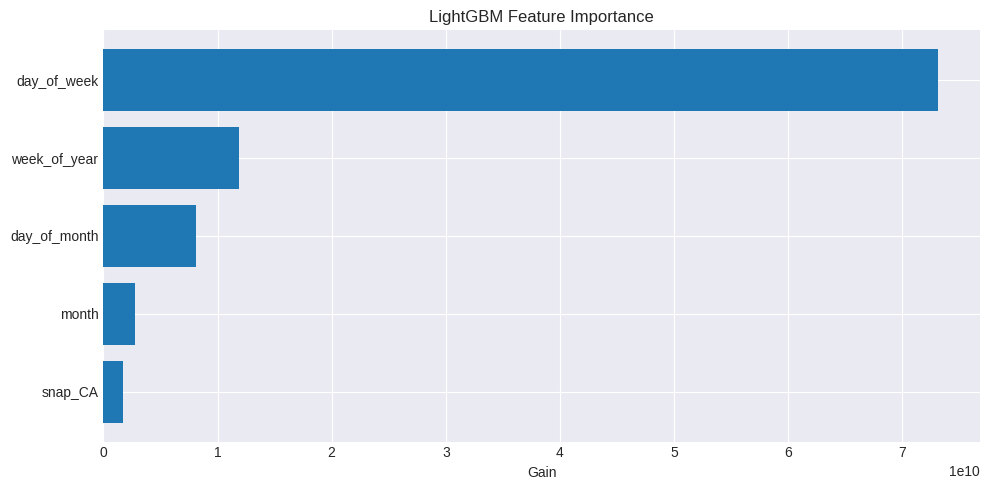


Full comparison:
Linear Reg          : 777
Ridge               : 789
SARIMAX             : 808
Holt-Winters        : 1073
SARIMA              : 1099
S-Naive             : 1305
Rolling             : 3299
ARIMA               : 3445
LightGBM            : 3801
Naive               : 4659


In [33]:
# we train on the previous same feature cols for comparison
cutoff = ca_df['date'].max() - pd.Timedelta(days=28)
train  = ca_df[ca_df['date'] <= cutoff]
test   = ca_df[ca_df['date'] >  cutoff]

feature_cols = [
    'day_of_week', 'day_of_month', 'week_of_year', 'month',
    
    'snap_CA'
]



X_train = train[feature_cols]
y_train = train['sales']
X_test  = test[feature_cols]
y_test  = test['sales']




lgb_train = lgb.Dataset(X_train,label=y_train)
lgb_val   = lgb.Dataset(X_test,  label=y_test, reference=lgb_train)

params = {
    'objective':      'regression',   # minimise RMSE
    'metric':         'rmse',
    'learning_rate':  0.05,           # how much each tree contributes
    'num_leaves':     31,             # max leaves per tree — controls complexity
    'min_data_in_leaf': 20,           # prevents overfitting on small groups
    'feature_fraction': 0.8,          # use 80% of features per tree (randomness)
    'bagging_fraction': 0.8,          # use 80% of data per tree (randomness)
    'bagging_freq':   5,
    'verbose':       -1               # suppress output
}

callbacks = [lgb.early_stopping(50), lgb.log_evaluation(100)]

model_lgb = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000,       # max trees to build
    valid_sets=[lgb_val],
    callbacks=callbacks         # stops if val RMSE doesn't improve for 50 rounds
)

print(f"Best iteration: {model_lgb.best_iteration}")

# ── 5. Predict and evaluate ───────────────────────────────────────────────────
f_lgb = model_lgb.predict(X_test)
rmse_lgb = np.sqrt(mean_squared_error(y_test, f_lgb))
print(f"LightGBM RMSE: {rmse_lgb:.2f}")


# ── 6. Feature Importance — most valuable part ────────────────────────────────
importance_df = pd.DataFrame({
    'feature':    feature_cols,
    'importance': model_lgb.feature_importance(importance_type='gain')
    # 'gain' = total reduction in error this feature caused across all trees
    # more meaningful than 'split' which just counts how often feature was used
}).sort_values('importance', ascending=False)

print("\nFeature importance:")
print(importance_df)

plt.figure(figsize=(10, 5))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Gain')
plt.title('LightGBM Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ── 9. Full model comparison ──────────────────────────────────────────────────
results = {
    'Naive':         4659,
    'S-Naive':       1305,
    'Rolling':       3299,
    'ARIMA':         3445,
    'SARIMA':        1099,
    'SARIMAX':        808,
    'Holt-Winters':  1073,
    'Linear Reg':     777,
    'Ridge':          789,
    'LightGBM':      rmse_lgb,
}
print("\nFull comparison:")
for model, rmse in sorted(results.items(), key=lambda x: x[1]):
    print(f"{model:20s}: {rmse:.0f}")

This entire experiment has revealed a hierarchy of what's actually driving your model performance:
1. Sales level (lag_7, lag_28)     → most important, carries everything
2. Weekly pattern (day_of_week)    → second, strong direct signal  
3. SNAP (snap_ca or day_of_month)  → third, but redundant given lags
4. Everything else                 → marginal
And the model ranking now makes complete sense:
Linear Regression (777)  → simple, right-sized for this data, has lags + snap
SARIMAX (808)            → time series structure + snap, well specified
LightGBM with lags (846) → overly complex for aggregated linear data
LightGBM no lags (≈4000) → blind to sales level, cannot forecast

### Important Takeaway Before Item Level
At state level, the dominant signal is the sales level itself — carried by lags. Everything else is secondary. SNAP matters, but it's temporally predictable enough that lags absorb it.
At item level this will break down because:

Item sales are sparse and noisy — lag_7 might be zero or a random spike, not a reliable level signal
SNAP effects are item-specific and non-linear — cat food responds differently than fresh produce
Price changes create discontinuities that lags cannot anticipate



# Item Level

## Section 1: Demand distribution across items

In [34]:
sales_long.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29


In [35]:
item_level = sales_long.groupby(['item_id','date'])['sales'].sum().reset_index()
item_level

,item_id,date,sales
0,FOODS_1_001,2011-01-29,6
1,FOODS_1_001,2011-01-30,6
2,FOODS_1_001,2011-01-31,4
3,FOODS_1_001,2011-02-01,6
4,FOODS_1_001,2011-02-02,7
...,...,...,...
5832732,HOUSEHOLD_2_516,2016-04-20,1
5832733,HOUSEHOLD_2_516,2016-04-21,2
5832734,HOUSEHOLD_2_516,2016-04-22,1
5832735,HOUSEHOLD_2_516,2016-04-23,0


In [36]:
item_means = item_level.groupby('item_id')['sales'].mean()
print(item_means.describe())
print(f"\nItems with mean sales < 1: {(item_means < 1).sum()}")
print(f"Items with mean sales < 0.5: {(item_means < 0.5).sum()}")

# Zero percentage per item
zero_pct = item_level.groupby('item_id').apply(
    lambda x: (x['sales'] == 0).mean()
)
print(f"\nZero % distribution:")
print(zero_pct.describe())
print(f"Items with >50% zeros: {(zero_pct > 0.5).sum()}")
print(f"Items with >80% zeros: {(zero_pct > 0.8).sum()}")

count    3049.000000
mean       11.263222
std        23.132480
min         0.296916
25%         2.253006
50%         4.979613
75%        11.189754
max       524.061160
Name: sales, dtype: float64

Items with mean sales < 1: 226
Items with mean sales < 0.5: 33

Zero % distribution:
count    3049.000000
mean        0.296853
std         0.233410
min         0.000523
25%         0.084684
50%         0.253528
75%         0.480920
max         0.899634
dtype: float64
Items with >50% zeros: 691
Items with >80% zeros: 16


In [49]:
zero_pct

item_id
FOODS_1_001        0.098275
FOODS_1_002        0.042865
FOODS_1_003        0.015682
FOODS_1_004        0.285938
FOODS_1_005        0.233142
                     ...   
HOUSEHOLD_2_512    0.015682
HOUSEHOLD_2_513    0.423419
HOUSEHOLD_2_514    0.296393
HOUSEHOLD_2_515    0.697334
HOUSEHOLD_2_516    0.321485
Length: 3049, dtype: float64

                 item_id       date  sales   category
0            FOODS_1_001 2011-01-29      6      FOODS
1            FOODS_1_001 2011-01-30      6      FOODS
2            FOODS_1_001 2011-01-31      4      FOODS
3            FOODS_1_001 2011-02-01      6      FOODS
4            FOODS_1_001 2011-02-02      7      FOODS
...                  ...        ...    ...        ...
5832732  HOUSEHOLD_2_516 2016-04-20      1  HOUSEHOLD
5832733  HOUSEHOLD_2_516 2016-04-21      2  HOUSEHOLD
5832734  HOUSEHOLD_2_516 2016-04-22      1  HOUSEHOLD
5832735  HOUSEHOLD_2_516 2016-04-23      0  HOUSEHOLD
5832736  HOUSEHOLD_2_516 2016-04-24      1  HOUSEHOLD

[5832737 rows x 4 columns]


/tmp/ipykernel_5062/3442740811.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(


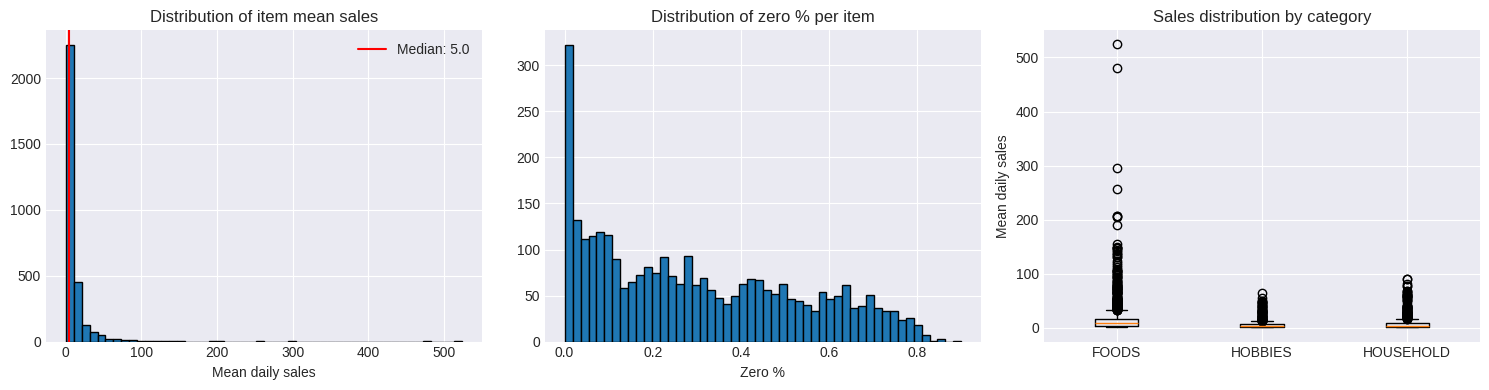

                mean  median        std
category                               
FOODS      16.402419     7.0  37.773272
HOBBIES     5.666677     2.0  11.439826
HOUSEHOLD   7.229812     3.0  14.193611

Zero % by category:
category
FOODS        0.272626
HOBBIES      0.327431
HOUSEHOLD    0.313604
Name: is_zero, dtype: float64


In [47]:
import matplotlib.pyplot as plt

item_means = item_level.groupby('item_id')['sales'].mean()
zero_pct = item_level.groupby('item_id').apply(
    lambda x: (x['sales'] == 0).mean()
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution of mean sales — will show the skew
axes[0].hist(item_means, bins=50, edgecolor='black')
axes[0].set_xlabel('Mean daily sales')
axes[0].set_title('Distribution of item mean sales')
axes[0].axvline(item_means.median(), color='red', 
                label=f'Median: {item_means.median():.1f}')
axes[0].legend()

# Distribution of zero %
axes[1].hist(zero_pct, bins=50, edgecolor='black')
axes[1].set_xlabel('Zero %')
axes[1].set_title('Distribution of zero % per item')

# Mean sales by category
cat_sales = item_level.copy()
cat_sales['category'] = cat_sales['item_id'].astype(str).str.split('_').str[0]
print(cat_sales)
cat_means = cat_sales.groupby(['category', 'item_id'])['sales'].mean().reset_index()
axes[2].boxplot(
    [cat_means[cat_means['category']==c]['sales'].values 
     for c in ['FOODS', 'HOBBIES', 'HOUSEHOLD']],
    labels=['FOODS', 'HOBBIES', 'HOUSEHOLD']
)
axes[2].set_ylabel('Mean daily sales')
axes[2].set_title('Sales distribution by category')

plt.tight_layout()
plt.show()

# Print category summary
print(cat_sales.groupby('category')['sales'].agg(['mean','median','std']))
print(f"\nZero % by category:")
cat_sales['is_zero'] = cat_sales['sales'] == 0
print(cat_sales.groupby('category')['is_zero'].mean())

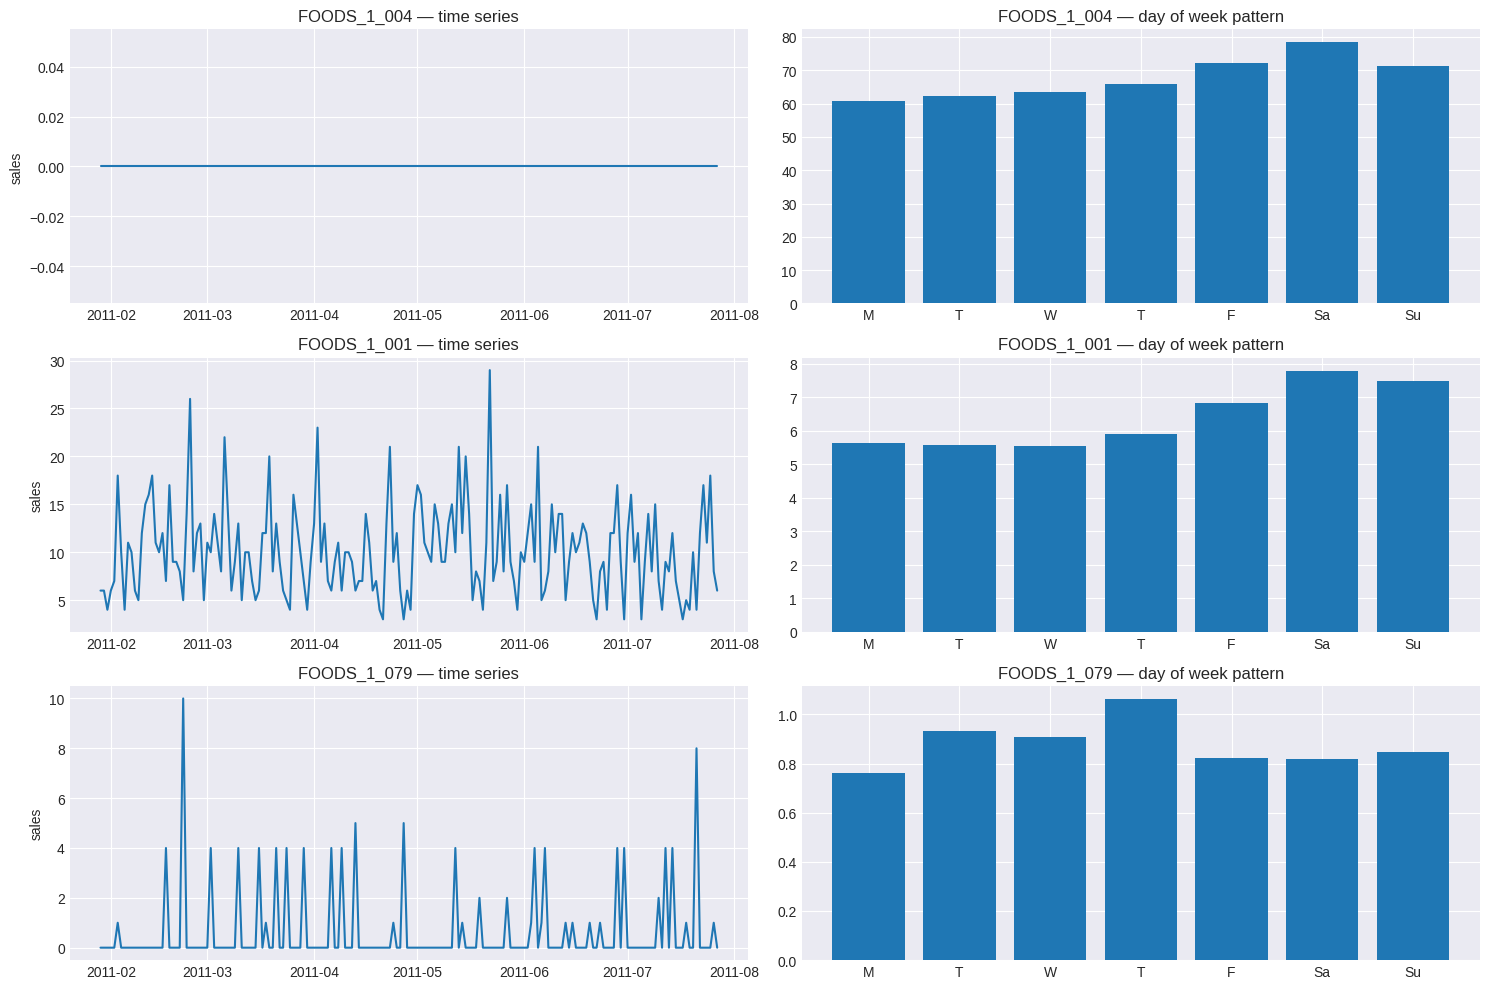

In [50]:


# High velocity FOODS item
high_vol = item_means[item_means > 50].index[0]

# Medium velocity  
med_vol = item_means[(item_means > 5) & (item_means < 10)].index[0]

# Low velocity / intermittent
low_vol = item_means[item_means < 1].index[0]

fig, axes = plt.subplots(3, 2, figsize=(15, 10))

for idx, item in enumerate([high_vol, med_vol, low_vol]):
    item_data = item_level[item_level['item_id'] == item].copy()
    item_data['day_of_week'] = pd.to_datetime(item_data['date']).dt.day_name()
    
    # Time series — first 6 months
    axes[idx, 0].plot(item_data['date'].iloc[:180], 
                      item_data['sales'].iloc[:180])
    axes[idx, 0].set_title(f'{item} — time series')
    axes[idx, 0].set_ylabel('sales')
    
    # Average by day of week
    dow_avg = item_data.groupby('day_of_week')['sales'].mean().reindex(
        ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
    )
    axes[idx, 1].bar(range(7), dow_avg.values)
    axes[idx, 1].set_xticks(range(7))
    axes[idx, 1].set_xticklabels(['M','T','W','T','F','Sa','Su'])
    axes[idx, 1].set_title(f'{item} — day of week pattern')

plt.tight_layout()
plt.show()

# Lower Heirarchical level and forecast